# Moving Earth, Counting Neighbors: Distribution Distances and Statistical Testing

In the 1940s, Leonid Kantorovich — later a Nobel laureate in economics — asked a question that seemed to have nothing to do with statistics: *what is the cheapest way to move a pile of earth from one shape to another?* Seven decades later, his optimal transport theory would become one of the hottest tools in machine learning, providing distances between distributions that work where information-theoretic divergences cannot.

This notebook explores a different family of distribution comparisons: **integral probability metrics** (IPMs) and **kNN-based estimators**. Unlike f-divergences, these methods work directly with point clouds — no density estimation, no logarithms, no concerns about support overlap.

**Note:** This builds on concepts from the [Divergence](Divergence.ipynb) notebook, where we covered entropy, KL divergence, and the classical information-theoretic toolkit.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from divergence import (
    energy_distance,
    entropy_from_samples,
    knn_entropy,
    knn_kl_divergence,
    ksg_mutual_information,
    maximum_mean_discrepancy,
    mutual_information_from_samples,
    relative_entropy_from_samples,
    sliced_wasserstein_distance,
    two_sample_test,
    wasserstein_distance,
)

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

from pathlib import Path
FIGURES_DIR = Path('figures/distances_and_testing')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. Setting the Stage

Every comparison needs something to compare. We begin with two univariate normal distributions that are visibly different — shifted in mean and spread — so the distances we compute will have clear geometric meaning. We also create a pair of 2D point clouds for the multivariate examples later.

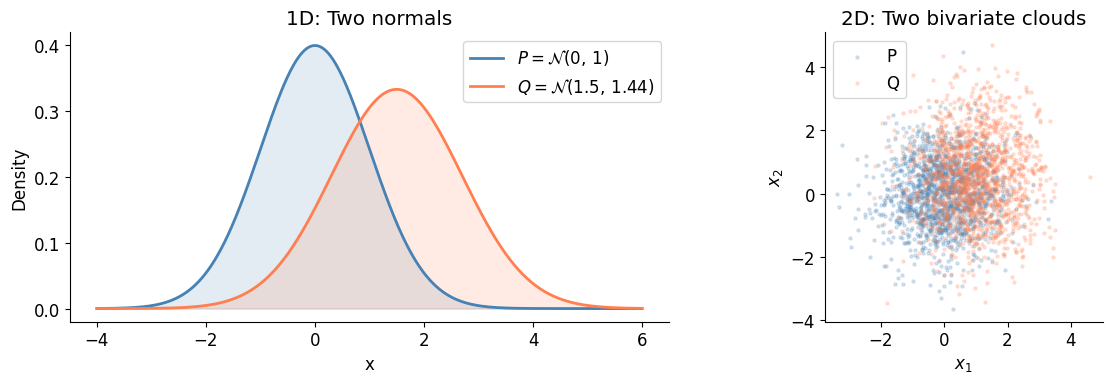

In [2]:
np.random.seed(42)
n = 5000

# 1D distributions
mu_p, sigma_p = 0.0, 1.0
mu_q, sigma_q = 1.5, 1.2

P = np.random.normal(mu_p, sigma_p, n)
Q = np.random.normal(mu_q, sigma_q, n)

# 2D distributions
P_2d = np.column_stack([np.random.normal(0, 1, n), np.random.normal(0, 1, n)])
Q_2d = np.column_stack([np.random.normal(1, 1, n), np.random.normal(0.5, 1.3, n)])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1D
x_grid = np.linspace(-4, 6, 500)
axes[0].plot(x_grid, stats.norm.pdf(x_grid, mu_p, sigma_p),
             color='steelblue', linewidth=2, label=r'$P = \mathcal{N}(0,\, 1)$')
axes[0].plot(x_grid, stats.norm.pdf(x_grid, mu_q, sigma_q),
             color='coral', linewidth=2, label=r'$Q = \mathcal{N}(1.5,\, 1.44)$')
axes[0].fill_between(x_grid, stats.norm.pdf(x_grid, mu_p, sigma_p), alpha=0.15, color='steelblue')
axes[0].fill_between(x_grid, stats.norm.pdf(x_grid, mu_q, sigma_q), alpha=0.15, color='coral')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].set_title('1D: Two normals')
axes[0].legend()

# 2D
axes[1].scatter(P_2d[:1500, 0], P_2d[:1500, 1], alpha=0.2, s=5, color='steelblue', label='P')
axes[1].scatter(Q_2d[:1500, 0], Q_2d[:1500, 1], alpha=0.2, s=5, color='coral', label='Q')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('2D: Two bivariate clouds')
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distributions_1d_2d.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 2. Wasserstein Distance — Moving Earth

In 1942, Leonid Kantorovich formulated the optimal transport problem while working in besieged Leningrad, trying to optimize resource allocation for the Soviet war effort. The mathematical distance that bears the name of Leonid Vasershtein — who formalized the metric-space properties in 1969 — answers a beautifully intuitive question: **what is the minimum cost of transforming one distribution into another?**

**Why it matters:** Unlike KL divergence, the Wasserstein distance is a *true metric* (symmetric, satisfies the triangle inequality) and is well-defined even when the distributions have non-overlapping support. This made it the key ingredient in Wasserstein GANs (Arjovsky et al., 2017), where KL-based training suffered from vanishing gradients.

For 1D distributions, the $p$-Wasserstein distance has a beautiful closed form in terms of quantile functions:

$$W_p(P, Q) = \left(\int_0^1 \left|F_P^{-1}(u) - F_Q^{-1}(u)\right|^p \, du\right)^{1/p}$$

The intuition: sort both samples, pair them up in rank order, and measure the total cost of rearrangement. For $p=1$ this is simply the area between the two CDFs.

In [3]:
# Wasserstein distances
w1 = wasserstein_distance(P, Q, p=1)
w2 = wasserstein_distance(P, Q, p=2)

# Verify W1 against scipy
w1_scipy = stats.wasserstein_distance(P, Q)

# Analytical W2 for normals: sqrt((mu1 - mu2)^2 + (sigma1 - sigma2)^2)
w2_analytical = np.sqrt((mu_p - mu_q)**2 + (sigma_p - sigma_q)**2)

print(f'W1(P, Q)  = {w1:.4f}   (scipy: {w1_scipy:.4f})')
print(f'W2(P, Q)  = {w2:.4f}   (analytical: {w2_analytical:.4f})')
print(f'\nW2 for normals = sqrt((mu1-mu2)^2 + (sigma1-sigma2)^2)')
print(f'              = sqrt({(mu_p-mu_q)**2:.2f} + {(sigma_p-sigma_q)**2:.2f}) = {w2_analytical:.4f}')

W1(P, Q)  = 1.4825   (scipy: 1.4825)
W2(P, Q)  = 1.4986   (analytical: 1.5133)

W2 for normals = sqrt((mu1-mu2)^2 + (sigma1-sigma2)^2)
              = sqrt(2.25 + 0.04) = 1.5133


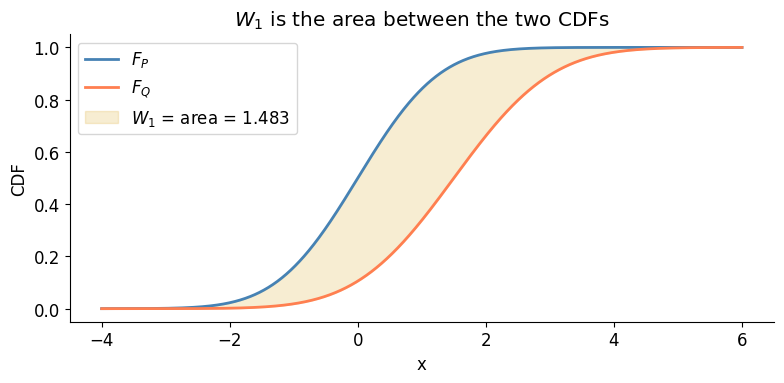

In [4]:
# Visualize W1 as the area between CDFs
fig, ax = plt.subplots(figsize=(8, 4))

x_cdf = np.linspace(-4, 6, 1000)
cdf_p = stats.norm.cdf(x_cdf, mu_p, sigma_p)
cdf_q = stats.norm.cdf(x_cdf, mu_q, sigma_q)

ax.plot(x_cdf, cdf_p, color='steelblue', linewidth=2, label=r'$F_P$')
ax.plot(x_cdf, cdf_q, color='coral', linewidth=2, label=r'$F_Q$')
ax.fill_between(x_cdf, cdf_p, cdf_q, alpha=0.2, color='goldenrod',
                label=f'$W_1$ = area = {w1:.3f}')
ax.set_xlabel('x')
ax.set_ylabel('CDF')
ax.set_title(r'$W_1$ is the area between the two CDFs')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'wasserstein_cdf_area.png', dpi=300, bbox_inches='tight')
plt.show()

### Sliced Wasserstein for higher dimensions

Computing optimal transport in high dimensions is expensive ($O(n^3 \log n)$ for the exact LP). The **sliced Wasserstein distance** sidesteps this by projecting both distributions onto many random 1D directions and averaging the cheap 1D Wasserstein distances:

$$SW_p(P, Q) = \left(\mathbb{E}_{\theta \sim \mathrm{Uniform}(S^{d-1})} \left[W_p^p(\theta^\top_{\#} P,\, \theta^\top_{\#} Q)\right]\right)^{1/p}$$

This is fast ($O(n \log n)$ per projection), parallelizable, and still a valid metric.

Sliced Wasserstein (2D, 200 projections): SW2 = 0.8167


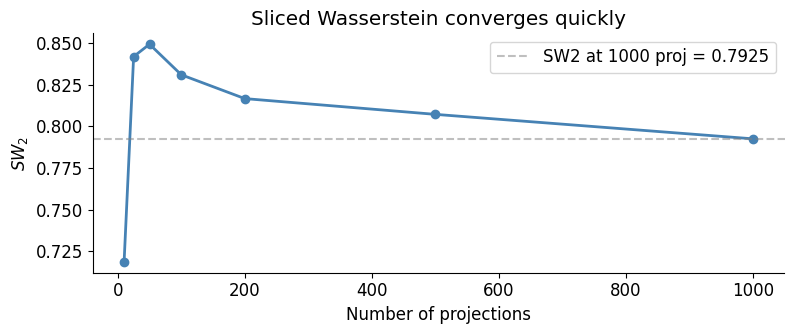

In [5]:
sw2 = sliced_wasserstein_distance(P_2d, Q_2d, n_projections=200, p=2, seed=42)
print(f'Sliced Wasserstein (2D, 200 projections): SW2 = {sw2:.4f}')

# Show convergence with number of projections
n_proj_values = [10, 25, 50, 100, 200, 500, 1000]
sw_values = [sliced_wasserstein_distance(P_2d, Q_2d, n_projections=k, p=2, seed=42)
             for k in n_proj_values]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(n_proj_values, sw_values, 'o-', color='steelblue', linewidth=2)
ax.axhline(sw_values[-1], color='gray', linestyle='--', alpha=0.5, label=f'SW2 at 1000 proj = {sw_values[-1]:.4f}')
ax.set_xlabel('Number of projections')
ax.set_ylabel('$SW_2$')
ax.set_title('Sliced Wasserstein converges quickly')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sliced_wasserstein_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 3. Energy Distance — Székely's Elegant Formula

In the early 2000s, Gábor Székely and Maria Rizzo — a Hungarian-American statistician and his collaborator at Bowling Green State University — introduced **energy distance**, drawing on an analogy with gravitational potential energy. Their 2004 and 2013 papers showed that this deceptively simple formula characterizes equality of distributions in *any* dimension:

$$\mathcal{E}(P, Q) = 2\,\mathbb{E}\|X - Y\| - \mathbb{E}\|X - X'\| - \mathbb{E}\|Y - Y'\|$$

where $X, X' \sim P$ and $Y, Y' \sim Q$ are independent copies.

**Why it matters:** No kernels, no bandwidth, no density estimates — just Euclidean distances between points. Energy distance is symmetric, non-negative, zero if and only if $P = Q$, and works in any dimension. It powers one of the simplest and most robust two-sample tests available.

In [6]:
# 1D energy distance
ed_1d = energy_distance(P, Q)
print(f'Energy distance (1D): {ed_1d:.4f}')

# 2D energy distance
ed_2d = energy_distance(P_2d, Q_2d)
print(f'Energy distance (2D): {ed_2d:.4f}')

# Sanity check: same distribution should give ~0
ed_same = energy_distance(P, np.random.normal(mu_p, sigma_p, n))
print(f'Energy distance (P vs P\'):  {ed_same:.4f}  (should be near 0)')

Energy distance (1D): 1.0496
Energy distance (2D): 0.4890
Energy distance (P vs P'):  0.0002  (should be near 0)


---
## 4. Maximum Mean Discrepancy — The Kernel Trick for Distributions

In 2006, Arthur Gretton and colleagues at UCL's Gatsby Computational Neuroscience Unit asked: what if we mapped entire distributions into a reproducing kernel Hilbert space (RKHS) and simply compared their *means* there? The result was the **Maximum Mean Discrepancy** (MMD), published in its definitive form in JMLR 2012.

**Why it matters:** With a *characteristic* kernel (like the RBF/Gaussian kernel), MMD is zero if and only if $P = Q$. The kernel implicitly maps samples into an infinite-dimensional feature space where even subtle distributional differences become detectable — no explicit feature engineering needed.

The squared MMD with RBF kernel $k(x,y) = \exp(-\|x-y\|^2 / 2\sigma^2)$ is estimated via the unbiased U-statistic:

$$\widehat{\text{MMD}}^2_u = \frac{1}{m(m-1)}\sum_{i \neq j} k(x_i, x_j) - \frac{2}{mn}\sum_{i,j} k(x_i, y_j) + \frac{1}{n(n-1)}\sum_{i \neq j} k(y_i, y_j)$$

The **median heuristic** sets the bandwidth $\sigma$ to the median of all pairwise distances in the pooled sample — a simple, parameter-free default that works well in practice.

**Important detail:** Because this is a U-statistic estimator, it can produce *slightly negative* values even when $\text{MMD}^2 \geq 0$ in expectation. This is normal estimation noise, not a bug.

In [7]:
# Use smaller samples for MMD (O(n^2) computation)
n_mmd = 2000
P_small = P[:n_mmd]
Q_small = Q[:n_mmd]

mmd_pq = maximum_mean_discrepancy(P_small, Q_small)
print(f'MMD^2(P, Q) = {mmd_pq:.6f}')

# Same distribution should give ~0 (may be slightly negative)
P_other = np.random.normal(mu_p, sigma_p, n_mmd)
mmd_same = maximum_mean_discrepancy(P_small, P_other)
print(f'MMD^2(P, P\') = {mmd_same:.6f}  (near 0, may be slightly negative)')

MMD^2(P, Q) = 0.274796


MMD^2(P, P') = 0.000255  (near 0, may be slightly negative)


### Detecting distribution shift

A common real-world scenario: you have a "baseline" dataset and a new batch arrives. Has the distribution shifted? Let's simulate a subtle shift and see which metrics catch it.

In [8]:
# Baseline vs. shifted data (subtle mean shift of 0.3)
baseline = np.random.normal(0, 1, 1000)
shifted = np.random.normal(0.3, 1, 1000)
no_shift = np.random.normal(0, 1, 1000)

print('Detecting a subtle mean shift of 0.3:')
print(f'  MMD^2 (no shift):  {maximum_mean_discrepancy(baseline, no_shift):.6f}')
print(f'  MMD^2 (shifted):   {maximum_mean_discrepancy(baseline, shifted):.6f}')
print(f'  Energy (no shift): {energy_distance(baseline, no_shift):.6f}')
print(f'  Energy (shifted):  {energy_distance(baseline, shifted):.6f}')
print(f'  W1 (no shift):     {wasserstein_distance(baseline, no_shift, p=1):.6f}')
print(f'  W1 (shifted):      {wasserstein_distance(baseline, shifted, p=1):.6f}')

Detecting a subtle mean shift of 0.3:
  MMD^2 (no shift):  0.002061
  MMD^2 (shifted):   0.026562
  Energy (no shift): 0.006778
  Energy (shifted):  0.080301
  W1 (no shift):     0.129936
  W1 (shifted):      0.382951


---
## 5. kNN Entropy — Density-Free Information Theory

In 1987, Kozachenko and Leonenko — two Soviet mathematicians working in Kharkiv — showed that you can estimate the differential entropy of a distribution *without ever estimating its density*. Their insight: the entropy is encoded in the distances to nearest neighbors. If points are tightly packed, density is high and entropy is low; if points are spread apart, density is low and entropy is high.

**Why it matters:** KDE-based entropy estimation struggles in dimensions above 3–4 due to the curse of dimensionality. The kNN estimator sidesteps this entirely by working with neighbor distances, making it practical in 10, 20, or even 100 dimensions.

The estimator:

$$\hat{H} = \frac{d}{N} \sum_{i=1}^{N} \ln \varepsilon_k(i) + \ln(N-1) - \psi(k) + \ln(c_d)$$

where $\varepsilon_k(i)$ is the distance to the $k$-th nearest neighbor, $c_d$ is the volume of the $d$-dimensional unit ball, and $\psi$ is the digamma function.

In [9]:
# Analytical entropy of N(0, 1): H = 0.5 * (1 + ln(2*pi*sigma^2))
H_analytical = 0.5 * (1 + np.log(2 * np.pi * sigma_p**2))

# kNN estimate
H_knn = knn_entropy(P, k=5)

# KDE estimate for comparison
H_kde = entropy_from_samples(P)

print(f'Entropy of N(0, 1):')
print(f'  Analytical:  {H_analytical:.4f} nats')
print(f'  kNN (k=5):   {H_knn:.4f} nats')
print(f'  KDE:         {H_kde:.4f} nats')
print(f'\n  kNN error:   {abs(H_knn - H_analytical):.4f}')
print(f'  KDE error:   {abs(H_kde - H_analytical):.4f}')

Entropy of N(0, 1):
  Analytical:  1.4189 nats
  kNN (k=5):   1.4287 nats
  KDE:         1.4321 nats

  kNN error:   0.0098
  KDE error:   0.0132


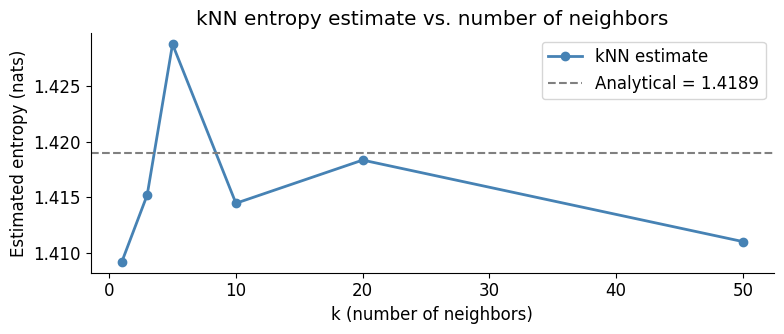

In [10]:
# Effect of k on the estimate
k_values = [1, 3, 5, 10, 20, 50]
h_estimates = [knn_entropy(P, k=k) for k in k_values]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(k_values, h_estimates, 'o-', color='steelblue', linewidth=2, label='kNN estimate')
ax.axhline(H_analytical, color='gray', linestyle='--', linewidth=1.5,
           label=f'Analytical = {H_analytical:.4f}')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Estimated entropy (nats)')
ax.set_title('kNN entropy estimate vs. number of neighbors')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'knn_entropy_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 6. kNN KL Divergence — Divergence Without Densities

In 2009, Wang, Kulkarni, and Verdú at Princeton showed how to estimate the KL divergence using kNN distances from *two* independent samples, completely bypassing density estimation. The key idea: build a KD-tree for each sample, then compare the neighbor distances.

$$\hat{D}_{KL}(P \| Q) = \frac{d}{n} \sum_{i=1}^{n} \ln\!\left(\frac{\nu_k(i)}{\rho_k(i)}\right) + \ln\!\left(\frac{m}{n-1}\right)$$

where $\rho_k(i)$ is the $k$-th neighbor distance in the P-sample and $\nu_k(i)$ is the $k$-th neighbor distance in the Q-sample.

**When to use kNN vs. KDE:** KDE-based KL estimation requires reliable density estimates for *both* distributions, which deteriorates rapidly above 2–3 dimensions. The kNN estimator scales gracefully because it only uses distance ratios, making it the method of choice for moderate-to-high-dimensional problems.

In [11]:
# Analytical KL between normals
def normal_kl(mu1, s1, mu2, s2):
    return np.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5

KL_analytical = normal_kl(mu_p, sigma_p, mu_q, sigma_q)

# kNN estimate
KL_knn = knn_kl_divergence(P, Q, k=5)

# KDE estimate for comparison
KL_kde = relative_entropy_from_samples(P, Q)

print(f'KL(P || Q) for N(0,1) || N(1.5, 1.44):')
print(f'  Analytical:  {KL_analytical:.4f} nats')
print(f'  kNN (k=5):   {KL_knn:.4f} nats')
print(f'  KDE:         {KL_kde:.4f} nats')
print(f'\n  kNN error:   {abs(KL_knn - KL_analytical):.4f}')
print(f'  KDE error:   {abs(KL_kde - KL_analytical):.4f}')

KL(P || Q) for N(0,1) || N(1.5, 1.44):
  Analytical:  0.8108 nats
  kNN (k=5):   0.7619 nats
  KDE:         0.7620 nats

  kNN error:   0.0489
  KDE error:   0.0488


---
## 7. KSG Mutual Information — Capturing All Dependence

In 2004, Alexander Kraskov, Harald Stögbauer, and Peter Grassberger at the Jülich Research Centre in Germany published what has become the gold standard for non-parametric mutual information estimation. Their **KSG estimator** uses kNN distances in the joint space $(X, Y)$ and counts neighbors in the marginal spaces, yielding a bias-corrected estimate that works remarkably well even in moderate dimensions.

**Why it matters:** Mutual information captures *all* statistical dependence — linear and nonlinear. Pearson correlation only sees linear relationships. This makes MI indispensable for feature selection, neuroscience, and any setting where the relationship between variables might be complex.

The killer demonstration: create a **nonlinear** relationship where Pearson $r \approx 0$ but $I(X; Y) > 0$.

In [12]:
# Nonlinear relationship: Y = sin(2*pi*X) + noise
# Using X ~ N(0,1) so sin covers many full cycles and linear correlation
# is truly near zero (with X ~ Uniform the integral of x*sin(2*pi*x) is
# nonzero, giving a spurious linear component)
np.random.seed(42)
n_mi = 3000
X_nonlin = np.random.randn(n_mi)
Y_nonlin = np.sin(2 * np.pi * X_nonlin) + 0.3 * np.random.randn(n_mi)

# Pearson correlation
r_pearson = np.corrcoef(X_nonlin, Y_nonlin)[0, 1]

# KSG mutual information
mi_ksg = ksg_mutual_information(X_nonlin, Y_nonlin, k=5)

# KDE mutual information for comparison
mi_kde = mutual_information_from_samples(X_nonlin, Y_nonlin)

print(f'Nonlinear relationship: Y = sin(2*pi*X) + noise')
print(f'  Pearson r:         {r_pearson:.4f}  (near zero — correlation is blind)')
print(f'  KSG MI (k=5):      {mi_ksg:.4f} nats  (substantial — MI sees it)')
print(f'  KDE MI:            {mi_kde:.4f} nats')

Nonlinear relationship: Y = sin(2*pi*X) + noise
  Pearson r:         -0.0289  (near zero — correlation is blind)
  KSG MI (k=5):      0.8285 nats  (substantial — MI sees it)
  KDE MI:            0.1905 nats


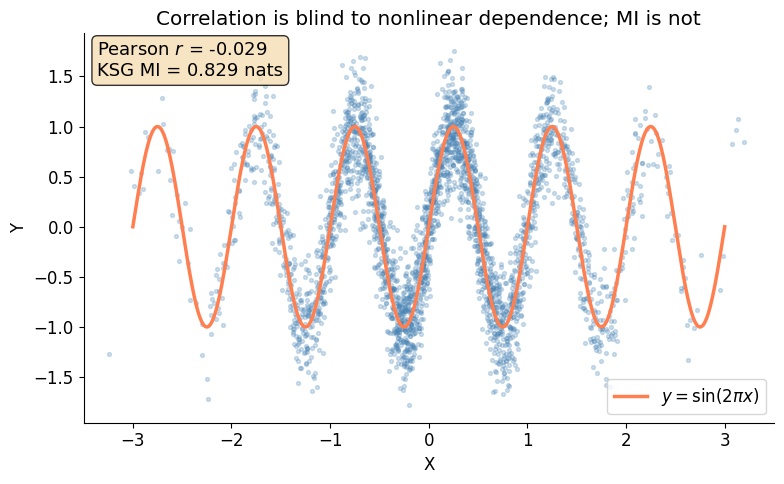

In [13]:
# The key plot: scatter with annotations
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(X_nonlin, Y_nonlin, alpha=0.25, s=8, color='steelblue')

# Overlay the true function
x_curve = np.linspace(-3, 3, 500)
ax.plot(x_curve, np.sin(2 * np.pi * x_curve), color='coral', linewidth=2.5,
        label=r'$y = \sin(2\pi x)$')

# Annotation box
textstr = f'Pearson $r$ = {r_pearson:.3f}\nKSG MI = {mi_ksg:.3f} nats'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim(-3.5, 3.5)
ax.set_title('Correlation is blind to nonlinear dependence; MI is not')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_vs_mutual_information.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Also verify with a linear relationship for calibration
rho_lin = 0.7
X_lin = np.random.normal(0, 1, n_mi)
Y_lin = rho_lin * X_lin + np.sqrt(1 - rho_lin**2) * np.random.randn(n_mi)

mi_lin_analytical = -0.5 * np.log(1 - rho_lin**2)
mi_lin_ksg = ksg_mutual_information(X_lin, Y_lin, k=5)

print(f'Linear case (rho = {rho_lin}):')
print(f'  Analytical MI:  {mi_lin_analytical:.4f} nats')
print(f'  KSG MI:         {mi_lin_ksg:.4f} nats')
print(f'  Pearson r:      {np.corrcoef(X_lin, Y_lin)[0,1]:.4f}')

Linear case (rho = 0.7):
  Analytical MI:  0.3367 nats
  KSG MI:         0.3542 nats
  Pearson r:      0.7148


---
## 8. Two-Sample Testing — Is the Difference Real?

Distances and divergences quantify *how different* two distributions are, but the critical question in practice is: **is the observed difference statistically significant, or could it be due to chance?**

The **permutation test** is the oldest and most elegant framework for answering this. Its logic, formalized by Ronald Fisher in the 1930s, is beautifully simple: if the two samples really come from the same distribution, then their labels ("P" vs. "Q") are arbitrary. Shuffle the labels many times, recompute the test statistic each time, and see where the original statistic falls in this null distribution.

**Key properties:**
- **Exact** under $H_0$: valid for any sample size, no asymptotic approximation needed
- **Non-parametric**: no distributional assumptions
- **Flexible**: any distance or divergence can serve as the test statistic

In [15]:
np.random.seed(42)
n_test = 300

# Case 1: Same distribution (should NOT reject)
A_same = np.random.normal(0, 1, n_test)
B_same = np.random.normal(0, 1, n_test)

# Case 2: Different distribution (should reject)
A_diff = np.random.normal(0, 1, n_test)
B_diff = np.random.normal(0.5, 1, n_test)

result_same = two_sample_test(A_same, B_same, method='energy', n_permutations=999, seed=42)
result_diff = two_sample_test(A_diff, B_diff, method='energy', n_permutations=999, seed=42)

print('=== Energy distance two-sample test ===')
print(f'\nSame distribution:')
print(f'  Statistic = {result_same.statistic:.4f},  p-value = {result_same.p_value:.4f}')
reject_same = 'YES' if result_same.p_value < 0.05 else 'NO'
print(f'  Reject H0 at alpha=0.05? {reject_same}')
print(f'\nDifferent distributions (mean shift = 0.5):')
print(f'  Statistic = {result_diff.statistic:.4f},  p-value = {result_diff.p_value:.4f}')
reject_diff = 'YES' if result_diff.p_value < 0.05 else 'NO'
print(f'  Reject H0 at alpha=0.05? {reject_diff}')

=== Energy distance two-sample test ===

Same distribution:
  Statistic = 0.0017,  p-value = 0.9730
  Reject H0 at alpha=0.05? NO

Different distributions (mean shift = 0.5):
  Statistic = 0.1688,  p-value = 0.0010
  Reject H0 at alpha=0.05? YES


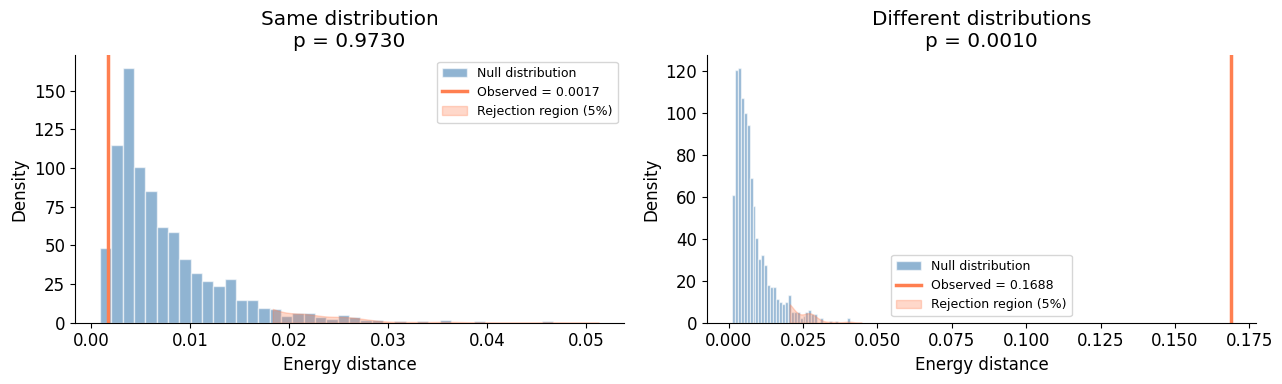

In [16]:
# Visualize the null distribution with the observed statistic
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, result, title in [(axes[0], result_same, 'Same distribution'),
                           (axes[1], result_diff, 'Different distributions')]:
    null = result.null_distribution
    obs = result.statistic

    ax.hist(null, bins=40, density=True, color='steelblue', alpha=0.6,
            edgecolor='white', label='Null distribution')
    ax.axvline(obs, color='coral', linewidth=2.5, linestyle='-',
               label=f'Observed = {obs:.4f}')

    # Shade the rejection region
    rejection_threshold = np.percentile(null, 95)
    x_shade = np.linspace(rejection_threshold, null.max() * 1.1, 100)
    # Use KDE for smooth shading
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(null)
    ax.fill_between(x_shade, kde(x_shade), alpha=0.3, color='coral',
                    label='Rejection region (5%)')

    ax.set_xlabel('Energy distance')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}\np = {result.p_value:.4f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'permutation_test.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparing test statistics: Energy vs. MMD

Different test statistics have different power profiles. Let's compare energy distance and MMD on the same data.

In [17]:
result_mmd = two_sample_test(A_diff, B_diff, method='mmd', n_permutations=999, seed=42)

print('Same data, different test statistics:')
print(f'  Energy: statistic = {result_diff.statistic:.4f}, p = {result_diff.p_value:.4f}')
print(f'  MMD:    statistic = {result_mmd.statistic:.6f}, p = {result_mmd.p_value:.4f}')

Same data, different test statistics:
  Energy: statistic = 0.1688, p = 0.0010
  MMD:    statistic = 0.060099, p = 0.0010


---
## 9. Which Distance to Use? A Decision Guide

With all these tools in our belt, how do we choose? The table below summarizes the key properties. There is no single best choice — the right tool depends on your data, your dimension, and your question.

| Measure | Symmetric? | Metric? | Needs density? | Dims | Best for |
|---------|-----------|---------|----------------|------|----------|
| Wasserstein ($W_p$) | Yes | Yes | No | 1D (exact), any (sliced) | Comparing distributions with geometric meaning; GANs |
| Energy distance | Yes | No* | No | Any | Simple, robust two-sample testing |
| MMD | Yes | Yes** | No | Any | Kernel-based testing; distribution shift detection |
| kNN entropy | — | — | No | Any | Entropy estimation in moderate-to-high dimensions |
| kNN KL divergence | No | No | No | Any | KL estimation when KDE fails (d > 3) |
| KSG mutual information | Yes | No | No | Any | Detecting nonlinear dependence |

\* Energy distance is not a metric in the strict sense (it does not satisfy the triangle inequality for all sample sizes), but $\sqrt{\mathcal{E}}$ is.  
\*\* MMD is a pseudometric; it is a metric when the kernel is characteristic (e.g., RBF).

### Practical recommendations

- **"Are these two samples from the same distribution?"** → Use `two_sample_test` with `method='energy'` (simple, no hyperparameters) or `method='mmd'` (more powerful with good bandwidth).
- **"How far apart are these distributions?"** → Use `wasserstein_distance` for interpretable 1D distances, `sliced_wasserstein_distance` for higher dimensions.
- **"How much does X tell me about Y?"** → Use `ksg_mutual_information` for nonlinear relationships, or `mutual_information_from_samples` for KDE-based estimation in 1D/2D.
- **"I need entropy in high dimensions."** → Use `knn_entropy`. KDE-based entropy breaks down above 3–4 dimensions.

### All distances on the same data

To build intuition for magnitudes, let's compute every distance on our two standard distributions side by side:

In [18]:
# Head-to-head comparison of all sample-based distances
P_cmp = np.random.normal(0, 1, 2000)
Q_cmp = np.random.normal(0.5, 1.5, 2000)

print(f'P ~ N(0, 1),  Q ~ N(0.5, 1.5²),  n = 2,000 each')
print()
print(f'{"Measure":<28} {"Value":>10}')
print('-' * 40)
print(f'{"Energy distance":<28} {energy_distance(P_cmp, Q_cmp):>10.4f}')
print(f'{"Wasserstein W₁":<28} {wasserstein_distance(P_cmp, Q_cmp, p=1):>10.4f}')
print(f'{"Wasserstein W₂":<28} {wasserstein_distance(P_cmp, Q_cmp, p=2):>10.4f}')
print(f'{"MMD² (RBF)":<28} {maximum_mean_discrepancy(P_cmp, Q_cmp):>10.4f}')
print(f'{"kNN KL divergence":<28} {knn_kl_divergence(P_cmp, Q_cmp):>10.4f}')
print(f'{"KSG mutual information":<28} {ksg_mutual_information(P_cmp, Q_cmp):>10.4f}')
print()
# Formal test: is the difference significant?
result = two_sample_test(P_cmp, Q_cmp, method='energy', n_permutations=500, seed=42)
print(f'Two-sample test (energy):  statistic = {result.statistic:.4f},  p = {result.p_value:.4f}')
result_mmd = two_sample_test(P_cmp, Q_cmp, method='mmd', n_permutations=500, seed=42)
print(f'Two-sample test (MMD):     statistic = {result_mmd.statistic:.4f},  p = {result_mmd.p_value:.4f}')

P ~ N(0, 1),  Q ~ N(0.5, 1.5²),  n = 2,000 each

Measure                           Value
----------------------------------------
Energy distance                  0.1579
Wasserstein W₁                   0.5757
Wasserstein W₂                   0.6933


MMD² (RBF)                       0.0613
kNN KL divergence                0.1754
KSG mutual information          -0.0084



Two-sample test (energy):  statistic = 0.1593,  p = 0.0020


Two-sample test (MMD):     statistic = 0.0613,  p = 0.0020


---
## 10. Where to Go from Here

This notebook covered distribution distances that work directly with samples — no density estimation required. Together with the information-theoretic measures in the [Divergence](Divergence.ipynb) notebook, the **Divergence** package provides a comprehensive toolkit for comparing probability distributions.

### References

- **Villani (2008)**, *Optimal Transport: Old and New* — the definitive monograph on transport distances
- **Gretton et al. (2012)**, *A Kernel Two-Sample Test*, JMLR — the MMD paper
- **Székely & Rizzo (2013)**, *Energy statistics*, J. Statistical Planning & Inference — energy distance and its testing framework
- **Kraskov, Stögbauer & Grassberger (2004)**, *Estimating Mutual Information*, Phys. Rev. E — the KSG estimator
- **Wang, Kulkarni & Verdú (2009)**, *Divergence estimation via k-nearest-neighbor distances*, IEEE Trans. Info. Theory
- **Kozachenko & Leonenko (1987)**, *Sample estimate of the entropy of a random vector*, Problems of Info. Transmission
- **Arjovsky, Chintala & Bottou (2017)**, *Wasserstein GAN*, ICML — the paper that brought optimal transport to deep learning

---

## The Divergence Notebook Series

| # | Notebook | What it covers |
|---|----------|---------------|
| 1 | [Divergence](Divergence.ipynb) | Shannon's foundations: entropy, cross entropy, KL divergence, Jensen-Shannon, mutual information, joint and conditional entropy |
| 2 | [Beyond KL](Beyond_KL.ipynb) | f-divergences (TV, Hellinger, chi-squared, Jeffreys, Cressie-Read) and the Rényi family |
| 3 | **Distances and Testing** *(this notebook)* | Sample-based methods: Wasserstein, energy distance, MMD, kNN estimators, two-sample permutation tests |
| 4 | [Dependence and Causality](Dependence_and_Causality.ipynb) | Multivariate dependence (TC, NMI, VI) and directed information flow (transfer entropy) |
| 5 | [Scores and Transport](Scores_and_Transport.ipynb) | The modern frontier: Fisher divergence, kernel Stein discrepancy, Sinkhorn divergence |
| 6 | [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) | End-to-end MCMC with emcee: convergence diagnostics, information gain, Bayesian surprise |
| 7 | [Real-World Applications](Real_World_Applications.ipynb) | Stock market contagion, crop yields, Phillips Curve — real data, real stakes |
| 8 | [Did My Sampler Find the Truth?](NumPyro_KSD.ipynb) | KSD as convergence diagnostic with NumPyro: NUTS vs VI, the 250-year journey from Bayes to Stein |